<h1 style="color:#4834DF; font-weight:700;">Normal Distribution:</h1>

- A normal distribution is a **`bell-shaped curve where most of the values are concentrated around the mean`**.

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

We are going to use heights dataset from kaggle.com. Dataset has heights and weights both but I removed weights to make it simple\
[Dataset](https://www.kaggle.com/mustafaali96/weight-height)

In [2]:
df = pd.read_csv("heights.csv") # heights are in inches
df.head()

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


### **(1) Outlier detection and removal using Standard Deviation**

In [3]:
df.height.describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: height, dtype: float64

In [4]:
df.height.info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: height
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 78.3 KB


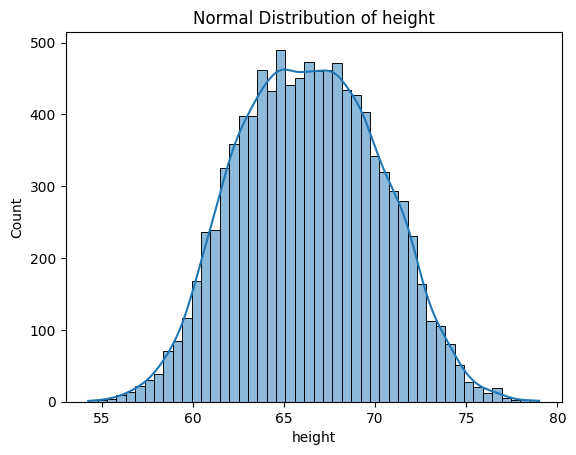

In [5]:
%matplotlib inline
sns.histplot(df.height,kde=True)
plt.title("Normal Distribution of height")
plt.show()

In [6]:
mean = df.height.mean()
print(mean)

66.367559754866


In [7]:
std_deviation = df.height.std()
print(std_deviation)

3.847528120795573


In [8]:
print(mean-3*std_deviation)

54.824975392479274


In [9]:
print(mean+3*std_deviation)

77.91014411725271


In [10]:
df[(df.height < 54.82) | (df.height > 77.91)]

,gender,height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [11]:
df_no_outlier = df[(df.height<77.91) & (df.height>54.82)]
df_no_outlier.shape

(9993, 2)

<h1 style="color:salmon; font-weight:700;">Z Score:</h1>

### **(2) Outlier detection and removal using Z Score**

- Z score is a way to achieve same thing that we did above in part (1)
- ***`Z score indicates how many standard deviation away a data point is`***.
   
- For example in our case mean is 66.37 and standard deviation is 3.84.
- If a value of a data point is 77.91 then Z score for that is 3 because it is 3 standard deviation away (77.91 = 66.37 + 3 * 3.84)

**Calculate the Z Score:**

<img src="img/zscore.png" alt="Z-score" width=300>

In [12]:
df['zscore'] = ( df.height - df.height.mean() ) / df.height.std()
df.head(5)

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


- Above for first record with height 73.84, z score is 1.94. This means 73.84 is 1.94 standard deviation away from mean

In [13]:
print(df.height.mean())

66.367559754866


In [14]:
print(df.height.std())

3.847528120795573


In [15]:
(73.84-66.37)/3.84

1.9453124999999998

In [16]:
df[df['zscore']>3]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [17]:
df[df['zscore']<-3]

,gender,height,zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


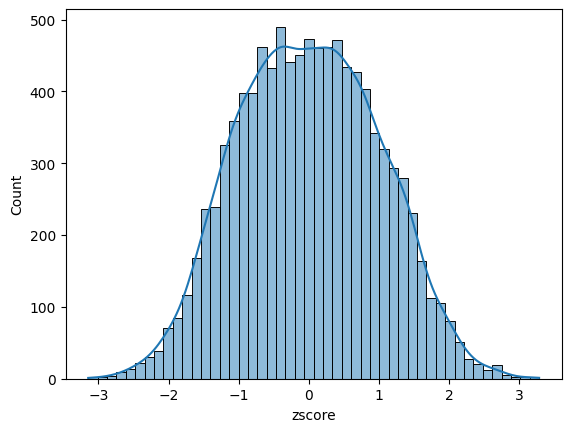

In [18]:
sns.histplot(df.zscore,kde=True)
plt.show()

**Other than +3,-3 std deviation the other points are outliers**